In [1]:
!pip install numpy==1.26.4 scipy==1.11.1

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   - -------------------------------------- 1.6/44.0 MB 8.4 MB/s eta 0:00:06
   - -------------------------------------- 2.1/44.0 MB 8.4 MB/s eta 0:00:06
   - -------------------------------------- 2.1/44.0 MB 8.4 MB/s eta 0:00:06
   - -------------------------------------- 2.1/44.0 MB 8.4 MB/s eta 0:00:06
   - -------------------------------------- 2.1/44.0 MB 8.4 MB/s eta 0:00:06
   -- ------------------------------------- 2.9/44.0 MB 2.2 MB/s eta 0:00:20
   ---- ----------------------------------- 5.2/44.0 MB 3.5 MB/s eta 0:00:11
   ---- ----------------------------------- 5.2/44.0 MB 3.5 MB/s eta 0:00:11
   ----- ---------------------------------- 6.0/44.0 MB 3.1 MB/s eta 0:00:13
   ------- -------------------------------- 8.1/44.0 MB 3.8 MB/s eta 0:00:10
   ------- -------------------------------- 8.4/44.0 MB 3.9 MB/s eta 0:00:10
   ------- -------------------------------- 8.4/44.0 MB 3.9 MB/s eta 0:00:10
   ---

In [2]:
!pip install gensim==4.3.1

   ---------------------------------------- 0.0/24.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.0 MB ? eta -:--:--
    --------------------------------------- 0.5/24.0 MB 1.4 MB/s eta 0:00:17
   - -------------------------------------- 0.8/24.0 MB 1.5 MB/s eta 0:00:16
   - -------------------------------------- 1.0/24.0 MB 1.4 MB/s eta 0:00:17
   -- ------------------------------------- 1.3/24.0 MB 1.3 MB/s eta 0:00:18
   -- ------------------------------------- 1.6/24.0 MB 1.4 MB/s eta 0:00:17
   --- ------------------------------------ 2.1/24.0 MB 1.5 MB/s eta 0:00:15
   ---- ----------------------------------- 2.6/24.0 MB 1.6 MB/s eta 0:00:14
   ----- ---------------------------------- 3.1/24.0 MB 1.7 MB/s eta 0:00:12
   ------ --------------------------------- 3.7/24.0 MB 1.9 MB/s eta 0:00:11
   ------- -------------------------------- 4.5/24.0 MB 2.0 MB/s eta 0:00:10
   -------- ------------------------------- 5.2/24.0 MB 2.2 MB/s eta 0:00:09
   -------- -

In [3]:
import gensim
print(gensim.__version__)

4.3.1


In [4]:
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [6]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [69]:
# Обучаем модель Word2Vec на нашем тексте
filename = '12-стульев.txt'  # файл с текстом
lemmatized_filename = '12-стульев_lemm.txt'  # файл для лемматизированного текста

In [33]:
pip install pymorphy2


Note: you may need to restart the kernel to use updated packages.


In [13]:
import pymorphy2

In [14]:
morph = pymorphy2.MorphAnalyzer()

In [71]:
# Считываем стоп-слова из файла
with open('swl.txt', 'r', encoding='utf-8') as f:
    stopwords = set(line.strip().lower() for line in f if line.strip())

In [70]:
# Лемматизация с удалением стоп-слов
with open(filename, 'r', encoding='utf-8') as fin, open(lemmatized_filename, 'w', encoding='utf-8') as fout:
    for line in fin:
        words = line.strip().split()
        lemmas = []
        for word in words:
            p = morph.parse(word)[0]
            lemma = p.normal_form
            if lemma not in stopwords:
                lemmas.append(lemma)
        fout.write(' '.join(lemmas) + '\n')

In [72]:
# Обучаем модель Word2Vec на нашем тексте

model = Word2Vec(
    LineSentence(filename),  # читаем файл построчно (предложения)
    vector_size=150,         # размер вектора для каждой слова
    window=1,                # сколько слов слева и справа учитываем
    min_count=5,             # игнорируем редкие слова (меньше 5)
    workers=2                # количество потоков для ускорения
)

model.init_sims(replace=True)  # оптимизация памяти
model.save('12стульев_lemm.model')     # сохраняем модель на диск

C:\Users\79040\AppData\Local\Temp\ipykernel_15712\3108574936.py:11: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  model.init_sims(replace=True)  # оптимизация памяти


In [73]:
# Загружаем модель
model = Word2Vec.load('12стульев_lemm.model')

In [74]:
# Функция, чтобы показать похожие слова
def print_similar_words(word, topn=10):
    print(f"Похожие слова для '{word}':")
    similar = model.wv.most_similar(positive=[word], topn=topn)
    for w, score in similar:
        print(f"  {w} -> {score:.4f}")
    print()

In [75]:
# Проверяем похожие слова для нескольких слов
words_to_test = ['деньги', 'стулья']
for w in words_to_test:
    print_similar_words(w)

Похожие слова для 'деньги':
  как -> 0.9992
  за -> 0.9992
  На -> 0.9991
  о -> 0.9991
  Он -> 0.9991
  Остап -> 0.9991
  ее -> 0.9991
  на -> 0.9991
  из -> 0.9991
  к -> 0.9991

Похожие слова для 'стулья':
  за -> 0.9988
  со -> 0.9988
  к -> 0.9987
  из -> 0.9987
  с -> 0.9986
  будет -> 0.9986
  По -> 0.9986
  в -> 0.9986
  что -> 0.9986
  Он -> 0.9986



In [76]:
# Считаем сходство между двумя словами
similarity_score = model.wv.similarity('стулья', 'деньги')
print(f"Сходство между 'стулья' и 'деньги': {similarity_score:.4f}\n")

Сходство между 'стулья' и 'деньги': 0.9982



Можно посчитать, насколько близки по смыслу два слова. Результат — число от -1 до 1 (больше значит более похожи).

In [47]:
# Функция для визуализации слов с помощью t-SNE
def tsnescatterplot(model, word, additional_words=[]):    ## строит вектора для заданного слова + его ближайших + дополнительных
    sns.set_style("darkgrid")    ## устанавливаем стиль графика

    arrays = np.empty((0, model.vector_size), dtype='f')  # массив векторов слов
    word_labels = [word]     # подписи слов на графике
    color_list = ['red']     # цвета для слов (красный — исходное слово)

    # Добавляем вектор исходного слова
    arrays = np.append(arrays, model.wv[word].reshape(1, -1), axis=0)

    # # Получаем 10 ближайших слов и добавляем их в массив векторов
    close_words = model.wv.most_similar([word], topn=10)
    for wrd, _ in close_words:
        arrays = np.append(arrays, model.wv[wrd].reshape(1, -1), axis=0)
        word_labels.append(wrd)     # # добавляем подпись
        color_list.append('blue')  # похожие слова — синие

    # Добавляем дополнительные слова (если есть)
    for wrd in additional_words:
        arrays = np.append(arrays, model.wv[wrd].reshape(1, -1), axis=0)
        word_labels.append(wrd)      # # добавляем подпись
        color_list.append('green')  # зелёныe - для вручную указанных слов

    # Сначала уменьшаем размерность до 4 с помощью PCA — ускоряет работу t-SNE
    pca_result = PCA(n_components=4).fit_transform(arrays)

    # Потом уменьшаем до 2D с помощью t-SNE для визуализации
    tsne = TSNE(n_components=2, perplexity=min(5, len(arrays)), n_iter=1000, random_state=0)
    tsne_result = tsne.fit_transform(pca_result)

    # Создаём таблицу для удобного рисования
    df = pd.DataFrame({
        'x': tsne_result[:, 0],      # координата X
        'y': tsne_result[:, 1],      # координата Y
        'word': word_labels,         # подпись (слово)
        'color': color_list          # цвет точки
    })

    # Рисуем график
    plt.figure(figsize=(10, 10))
    sns.scatterplot(data=df, x='x', y='y', hue='color', palette=['red', 'blue', 'green'], legend=False, s=100)

    # Подписываем слова рядом с точками
    for i in range(len(df)):
        plt.text(df.x[i]+0.1, df.y[i]+0.1, df.word[i], fontsize=12)

    plt.title(f't-SNE визуализация для слова: {word}')
    plt.show()

c:\Users\79040\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\79040\AppData\Local\Temp\ipykernel_15712\685251020.py:42: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.scatterplot(data=df, x='x', y='y', hue='color', palette=['red', 'blue', 'green'], legend=False, s=100)


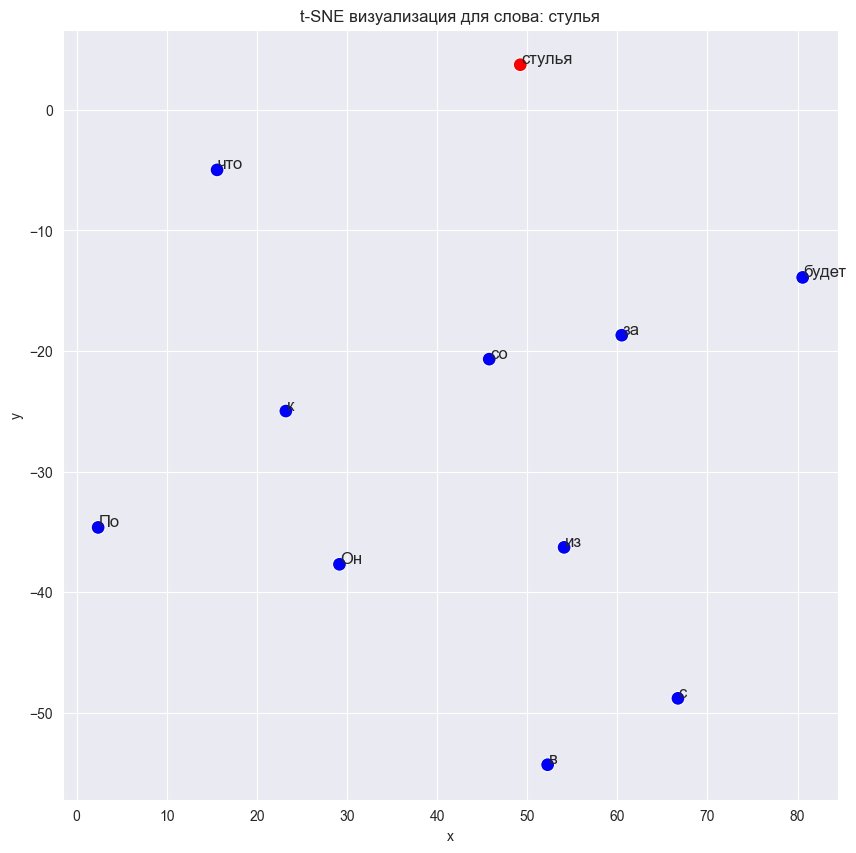

In [77]:
# Визуализируем слово 'стулья'
tsnescatterplot(model, 'стулья')

В этом задании мне нужно было обучить модель Word2Vec на корпусе произведения "12 стульев" (в лемматизированном виде), чтобы найти семантические связи между словами.

Сначала я использовала библиотеку Gensim, чтобы обучить модель Word2Vec на файле 12-стульев.txt. Я установила параметры — размер вектора, размер окна, минимальное количество вхождений. После обучения я сохранил модель.

Затем я загрузил эту модель и с помощью неё:

Нашла 10 самых похожих слов к выбранным словам (например, 'стулья', 'деньги').

Вычислила степень семантического сходства между двумя словами ('стулья', 'деньги').

Построила визуализацию с помощью t-SNE, чтобы показать, как слова расположены в векторном пространстве и какие из них ближе друг к другу по значению.

Для визуализации я сначала уменьшила размерность с помощью PCA до 4, а потом применила t-SNE для уменьшения до 2 измерений, и отобразила это с помощью графика в matplotlib и seaborn.

Таким образом, я продемонстрировала, что модель умеет находить семантически близкие слова и отображать их визуально.